# Melting Point 예측 — v6_chemberta (ChemBERTa Pretrained Embedding)

**차별점**: v5 피처(Morgan+MACCS+RDKit) + **ChemBERTa 768-dim embedding** concat

**공통**: 데이터, split, CV, VT, MI, 모델 아키텍처, 학습, 평가 모두 v5와 동일

**목표**: Test R² 0.7536 (v5) → 0.80~0.88

In [1]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib scikit-learn rdkit torch transformers -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings, time
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from rdkit import Chem
from rdkit.Chem import Descriptors, MACCSkeys
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from rdkit.Chem.Scaffolds import MurckoScaffold

from sklearn.model_selection import train_test_split, StratifiedKFold, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold, mutual_info_regression
from sklearn.cluster import KMeans
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


from transformers import AutoTokenizer, AutoModel
import platform, subprocess
if platform.system() == 'Linux':
    subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)
    import matplotlib.font_manager as fm
    fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
    plt.rcParams["font.family"] = "NanumGothic"
else:
    plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
T0 = time.time()
print("라이브러리 로드 완료")
print(f"디바이스: {DEVICE}")

라이브러리 로드 완료
디바이스: cpu


## 1. 데이터 로드

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/sunghee-sketch/middle-test/main/data/Melting_point_2.csv")
df = df.drop_duplicates().reset_index(drop=True)
df = df[df["MP"] >= 0].reset_index(drop=True)
df["MP_log"] = np.log1p(df["MP"])
print(f"데이터 크기: {df.shape}")
print(f"MP 범위: {df['MP'].min():.1f} ~ {df['MP'].max():.1f} K")
df.head()

데이터 크기: (2117, 3)
MP 범위: 13.9 ~ 1870.0 K


,SMILES,MP,MP_log
0,CCN(O)CC,247.650,5.516046
1,c1(C(C)=C)ccccc1,249.950,5.525254
2,C/C=C/CCCC,164.000,5.105945
3,c1(CC)cc(CC)cc(CC)c1,206.735,5.336263
4,COC(C)(C)C(=O)OC,229.600,5.440685


## 2. 피처 추출 (Morgan + MACCS + RDKit) + Murcko Scaffold
v5와 동일 — 2431차원 + scaffold. ChemBERTa 임베딩은 다음 셀에서 별도 추출 후 concat.

In [4]:
morgan_gen = GetMorganGenerator(radius=2, fpSize=2048)
desc_list  = [(n, f) for n, f in Descriptors.descList if not n.startswith("Ipc")]

def smiles_to_features_and_scaffold(smiles_list):
    records, scaffolds, valid_idx = [], [], []
    for i, smi in enumerate(smiles_list):
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            continue
        morgan = morgan_gen.GetFingerprintAsNumPy(mol).astype(np.float32)
        maccs  = np.array(MACCSkeys.GenMACCSKeys(mol), dtype=np.float32)
        descs  = []
        for _, func in desc_list:
            try:
                v = func(mol)
                descs.append(float(v) if (v is not None and np.isfinite(v)) else 0.0)
            except Exception:
                descs.append(0.0)
        records.append(np.concatenate([morgan, maccs, np.array(descs, np.float32)]))
        # Murcko scaffold (빈 scaffold면 SMILES 자체 사용)
        try:
            scaf = MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)
            scaffolds.append(scaf if scaf else smi)
        except Exception:
            scaffolds.append(smi)
        valid_idx.append(i)
    X = np.array(records, dtype=np.float32)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    return X, scaffolds, valid_idx

print("피처 + scaffold 추출 중...")
t = time.time()
X_all, scaffolds_all, valid_idx = smiles_to_features_and_scaffold(df["SMILES"].tolist())
y_all     = df["MP"].values[valid_idx]
y_all_log = df["MP_log"].values[valid_idx]
scaf_arr  = np.array(scaffolds_all)
n_unique_scaf = len(set(scaffolds_all))
print(f"유효 샘플: {len(valid_idx)} / {len(df)}  |  피처 차원: {X_all.shape[1]}  |  소요: {time.time()-t:.1f}s")
print(f"Unique scaffold 수: {n_unique_scaf} (전체 분자의 {n_unique_scaf/len(valid_idx):.1%})")

피처 + scaffold 추출 중...
유효 샘플: 2117 / 2117  |  피처 차원: 2431  |  소요: 7.5s
Unique scaffold 수: 1527 (전체 분자의 72.1%)


## 3. ChemBERTa 임베딩 추출 (차별점)
`seyonec/ChemBERTa-zinc-base-v1` (PubChem 77M pretrained, 768-dim). SMILES → `[CLS]` token → 768-dim.
첫 실행 시 HuggingFace에서 ~400MB 모델 다운로드 발생.

In [5]:
print("ChemBERTa 모델 로드 중 (첫 실행 시 ~400MB 다운로드)...")
t = time.time()
tokenizer = AutoTokenizer.from_pretrained("seyonec/ChemBERTa-zinc-base-v1")
bert_model = AutoModel.from_pretrained("seyonec/ChemBERTa-zinc-base-v1").to(DEVICE).eval()
print(f"모델 로드 완료: {time.time()-t:.1f}s")

@torch.no_grad()
def smiles_to_bert(smiles_list, batch_size=32):
    embs = []
    for i in range(0, len(smiles_list), batch_size):
        batch = smiles_list[i:i+batch_size]
        enc = tokenizer(batch, padding=True, truncation=True, max_length=128, return_tensors='pt').to(DEVICE)
        out = bert_model(**enc)
        cls_emb = out.last_hidden_state[:, 0, :].cpu().numpy()  # [CLS] pooling
        embs.append(cls_emb)
        if (i // batch_size) % 10 == 0:
            print(f"  진행: {min(i+batch_size, len(smiles_list))}/{len(smiles_list)}  ({time.time()-t:.0f}s)")
    return np.vstack(embs).astype(np.float32)

print("SMILES → ChemBERTa 임베딩 추출 중...")
valid_smiles = [df['SMILES'].iloc[i] for i in valid_idx]
bert_emb = smiles_to_bert(valid_smiles, batch_size=32)
print(f"ChemBERTa 임베딩: {bert_emb.shape}  |  총 소요: {time.time()-t:.0f}s")

# Concat with existing features
X_all_v5 = X_all.copy()  # 2431차원 보존
X_all = np.hstack([X_all, bert_emb]).astype(np.float32)
print(f"피처 concat: {X_all_v5.shape[1]} + {bert_emb.shape[1]} = {X_all.shape[1]}")

# Free model memory
del bert_model, tokenizer
import gc; gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

ChemBERTa 모델 로드 중 (첫 실행 시 ~400MB 다운로드)...
모델 로드 완료: 14.9s
SMILES → ChemBERTa 임베딩 추출 중...
  진행: 32/2117  (15s)
  진행: 352/2117  (17s)
  진행: 672/2117  (18s)
  진행: 992/2117  (20s)
  진행: 1312/2117  (21s)
  진행: 1632/2117  (22s)
  진행: 1952/2117  (24s)
ChemBERTa 임베딩: (2117, 768)  |  총 소요: 25s
피처 concat: 2431 + 768 = 3199


## 4. Step A — VarianceThreshold
피처 차원 변화 추적: 2431 (v5) → 3199 (v5+ChemBERTa) → VT 후

In [6]:
vt = VarianceThreshold(threshold=0.01)
X_all_vt = vt.fit_transform(X_all).astype(np.float32)
vt_mask = vt.get_support()
n_bert_kept = vt_mask[-768:].sum()
print(f"VarianceThreshold 전: {X_all.shape[1]} → 후: {X_all_vt.shape[1]} (제거: {X_all.shape[1] - X_all_vt.shape[1]})")
print(f"  ChemBERTa 768 중 VT 통과: {n_bert_kept} ({n_bert_kept/768:.1%})")

VarianceThreshold 전: 3199 → 후: 1272 (제거: 1927)
  ChemBERTa 768 중 VT 통과: 768 (100.0%)


## 5. Train/Test 분할 + 스케일링

In [7]:
mp_bins = pd.qcut(y_all, q=10, labels=False, duplicates="drop")
indices = np.arange(len(X_all_vt))
tr_i, te_i = train_test_split(
    indices, test_size=0.2, random_state=RANDOM_STATE, stratify=mp_bins
)
X_train, X_test = X_all_vt[tr_i], X_all_vt[te_i]
y_train, y_test = y_all[tr_i], y_all[te_i]
y_tr_log, y_te_log = y_all_log[tr_i].astype(np.float32), y_all_log[te_i].astype(np.float32)
scaf_train = scaf_arr[tr_i]

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train).astype(np.float32)
X_test_sc  = scaler.transform(X_test).astype(np.float32)
X_train_sc = np.nan_to_num(X_train_sc, nan=0.0, posinf=0.0, neginf=0.0)
X_test_sc  = np.nan_to_num(X_test_sc,  nan=0.0, posinf=0.0, neginf=0.0)
X_train_sc = np.clip(X_train_sc, -10.0, 10.0).astype(np.float32)
X_test_sc  = np.clip(X_test_sc,  -10.0, 10.0).astype(np.float32)

high_thr = np.percentile(y_train, 90)
sw_train = np.where(y_train >= high_thr, 3.0, 1.0).astype(np.float32)

print(f"Train: {X_train_sc.shape}  |  Test: {X_test_sc.shape}")
print(f"Train 분자의 unique scaffold: {len(set(scaf_train))}")

Train: (1693, 1272)  |  Test: (424, 1272)
Train 분자의 unique scaffold: 1236


## 6. MI top-K (ANN 최종 모델용) + ChemBERTa 생존율

In [8]:
TOP_K = 300
print(f"전체 train MI 계산 중...")
t = time.time()
mi_full = mutual_info_regression(X_train_sc, y_tr_log, random_state=RANDOM_STATE, n_neighbors=3)
top_idx_full = np.argsort(mi_full)[::-1][:TOP_K]
X_train_sel_full = X_train_sc[:, top_idx_full]
X_test_sel_full  = X_test_sc[:, top_idx_full]
print(f"MI top-{TOP_K} (full-train) 완료 — {time.time()-t:.1f}s")
print(f"MI 상위 5 평균: {mi_full[top_idx_full[:5]].mean():.4f}  |  하위 5 평균: {mi_full[top_idx_full[-5:]].mean():.4f}")

# VT 후 피처 구성: Morgan→MACCS→RDKit→ChemBERTa 순서
# VT 마스크로 ChemBERTa 원본 위치 역추적
n_pre_bert = vt_mask[:-768].sum()   # ChemBERTa 제외 VT 통과 수
bert_in_top_K = sum(1 for idx in top_idx_full if idx >= n_pre_bert)
print(f"MI top-{TOP_K} 중 ChemBERTa 비중: {bert_in_top_K} ({bert_in_top_K/TOP_K:.1%})")

전체 train MI 계산 중...
MI top-300 (full-train) 완료 — 3.8s
MI 상위 5 평균: 0.2786  |  하위 5 평균: 0.1225
MI top-300 중 ChemBERTa 비중: 7 (2.3%)


## 7. 모델 정의 — ResidualMLP + Mixup (v5 동일)

In [9]:
class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.3):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim)
        self.fc2 = nn.Linear(dim, dim)
        self.ln1 = nn.LayerNorm(dim)
        self.ln2 = nn.LayerNorm(dim)
        self.act = nn.SiLU()
        self.drop = nn.Dropout(dropout)
    def forward(self, x):
        h = self.drop(self.act(self.ln1(self.fc1(x))))
        h = self.ln2(self.fc2(h))
        return x + h  # skip 직후 act 제거 (distribution shift 방지)

class ResidualMLP(nn.Module):
    def __init__(self, input_dim, hidden=256, n_blocks=3, dropout=0.3):
        super().__init__()
        # 라운드 2: proj 후 LN (학습 초기 안정성 + pre-norm 효과)
        self.proj = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.LayerNorm(hidden),
        )
        self.blocks = nn.ModuleList([ResidualBlock(hidden, dropout) for _ in range(n_blocks)])
        self.head = nn.Sequential(
            nn.LayerNorm(hidden),  # head 입력 정규화
            nn.Linear(hidden, 64), nn.SiLU(), nn.Linear(64, 1),
        )
    def forward(self, x):
        x = self.proj(x)
        for b in self.blocks:
            x = b(x)
        return self.head(x).squeeze(1)

def mixup_batch(X, y, w, alpha=0.3):
    if alpha <= 0:
        return X, y, w
    lam = float(np.random.beta(alpha, alpha))
    idx = torch.randperm(X.size(0), device=X.device)
    X_m = lam * X + (1.0 - lam) * X[idx]
    y_m = lam * y + (1.0 - lam) * y[idx]
    w_m = lam * w + (1.0 - lam) * w[idx]  # weight 보간
    return X_m, y_m, w_m

def train_epoch(model, loader, optimizer, criterion, mixup_alpha=0.3, mixup_prob=0.5):
    model.train()
    total_loss = 0
    for X_b, y_b, w_b in loader:
        X_b, y_b, w_b = X_b.to(DEVICE), y_b.to(DEVICE), w_b.to(DEVICE)
        if np.random.rand() < mixup_prob:
            X_b, y_b, w_b = mixup_batch(X_b, y_b, w_b, alpha=mixup_alpha)
        optimizer.zero_grad()
        pred = model(X_b)
        loss = (criterion(pred, y_b) * w_b).mean()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

@torch.no_grad()
def predict(model, X_sc):
    model.eval()
    X_t = torch.tensor(X_sc).to(DEVICE)
    return model(X_t).cpu().numpy()

INPUT_DIM = TOP_K  # CV·final 모두 300차원
test_model = ResidualMLP(INPUT_DIM)
n_params = sum(p.numel() for p in test_model.parameters())
print(f"입력: {INPUT_DIM}  |  hidden=256  |  n_blocks=3  |  파라미터: {n_params:,}")

입력: 300  |  hidden=256  |  n_blocks=3  |  파라미터: 492,417


## 8. Stratified 5-Fold CV (v5 동일, Option B)

In [10]:
EPOCHS    = 200   # v4 80 → 200 (Fold 3 조기 종료 대응)
BATCH     = 128
LR        = 1e-3
PATIENCE  = 25    # v4 12 → 25
WD        = 5e-4
MIXUP_A   = 0.3
MIXUP_P   = 0.5
SCH_PAT   = 10    # v4 6 → 10

def run_cv(splits, X_full, y_full, sw_full, y_orig_full, label):
    """공통 CV 루프. splits: list of (tr_idx, val_idx)."""
    cv_r2, cv_mse, cv_mae, fold_overlaps, fold_epochs = [], [], [], [], []
    t_cv = time.time()
    for fold, (tr_idx, val_idx) in enumerate(splits, 1):
        t_fold = time.time()
        # Option B: fold-내부 MI fit
        mi_fold = mutual_info_regression(
            X_full[tr_idx], y_full[tr_idx],
            random_state=RANDOM_STATE + fold, n_neighbors=3,
        )
        top_idx_fold = np.argsort(mi_fold)[::-1][:TOP_K]
        overlap = len(set(top_idx_fold.tolist()) & set(top_idx_full.tolist())) / TOP_K
        fold_overlaps.append(overlap)

        X_tr  = X_full[tr_idx][:, top_idx_fold].astype(np.float32)
        X_val = X_full[val_idx][:, top_idx_fold].astype(np.float32)
        y_tr, y_val = y_full[tr_idx], y_full[val_idx]
        sw_tr        = sw_full[tr_idx]
        y_val_orig   = y_orig_full[val_idx]

        ds  = TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr), torch.tensor(sw_tr))
        ldr = DataLoader(ds, batch_size=BATCH, shuffle=True)

        torch.manual_seed(RANDOM_STATE + fold)
        np.random.seed(RANDOM_STATE + fold)
        model     = ResidualMLP(INPUT_DIM, hidden=256, n_blocks=3, dropout=0.3).to(DEVICE)
        optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WD)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=SCH_PAT, factor=0.5)
        criterion = nn.MSELoss(reduction="none")

        best_val_loss, patience_cnt, best_state = np.inf, 0, None
        for epoch in range(EPOCHS):
            train_epoch(model, ldr, optimizer, criterion, mixup_alpha=MIXUP_A, mixup_prob=MIXUP_P)
            val_pred_log = predict(model, X_val)
            val_loss = mean_squared_error(y_val, val_pred_log)
            scheduler.step(val_loss)
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state = {k: v.clone() for k, v in model.state_dict().items()}
                patience_cnt = 0
            else:
                patience_cnt += 1
            if patience_cnt >= PATIENCE:
                break

        model.load_state_dict(best_state)
        pred = np.expm1(predict(model, X_val))
        cv_r2.append(r2_score(y_val_orig, pred))
        cv_mse.append(mean_squared_error(y_val_orig, pred))
        cv_mae.append(mean_absolute_error(y_val_orig, pred))
        fold_epochs.append(epoch + 1)
        print(f"  [{label}] Fold {fold}  R²={cv_r2[-1]:.4f}  MSE={cv_mse[-1]:.0f}  MAE={cv_mae[-1]:.2f}  "
              f"(epoch {epoch+1}, overlap={overlap:.0%}, fold {time.time()-t_fold:.0f}s, 누적 {time.time()-t_cv:.0f}s)")
    return cv_r2, cv_mse, cv_mae, fold_overlaps, fold_epochs

print("=== Stratified 5-Fold CV (v3/v4 비교용) ===")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
mp_bins_train = pd.qcut(y_train, q=10, labels=False, duplicates="drop")
strat_splits = list(skf.split(X_train_sc, mp_bins_train))
strat_r2, strat_mse, strat_mae, strat_overlaps, strat_epochs = run_cv(
    strat_splits, X_train_sc, y_tr_log, sw_train, y_train, "Strat"
)
print(f"\nStratified CV 평균: R²={np.mean(strat_r2):.4f} ± {np.std(strat_r2):.4f}  "
      f"MAE={np.mean(strat_mae):.2f}  overlap 평균={np.mean(strat_overlaps):.1%}")

=== Stratified 5-Fold CV (v3/v4 비교용) ===
  [Strat] Fold 1  R²=0.7702  MSE=4220  MAE=35.37  (epoch 55, overlap=79%, fold 5s, 누적 5s)
  [Strat] Fold 2  R²=0.4718  MSE=12184  MAE=39.43  (epoch 89, overlap=78%, fold 7s, 누적 13s)
  [Strat] Fold 3  R²=0.5225  MSE=9991  MAE=37.43  (epoch 70, overlap=80%, fold 6s, 누적 19s)
  [Strat] Fold 4  R²=0.6837  MSE=8313  MAE=39.01  (epoch 39, overlap=80%, fold 6s, 누적 25s)
  [Strat] Fold 5  R²=0.7327  MSE=11033  MAE=44.07  (epoch 46, overlap=81%, fold 5s, 누적 30s)

Stratified CV 평균: R²=0.6362 ± 0.1179  MAE=39.06  overlap 평균=79.9%


## 9. Scaffold 5-Fold CV

In [11]:
print("=== Scaffold 5-Fold CV (Murcko GroupKFold) ===")
gkf = GroupKFold(n_splits=5)
scaf_splits = list(gkf.split(X_train_sc, y_tr_log, groups=scaf_train))
scaf_r2, scaf_mse, scaf_mae, scaf_overlaps, scaf_epochs = run_cv(
    scaf_splits, X_train_sc, y_tr_log, sw_train, y_train, "Scaf"
)
print(f"\nScaffold CV 평균: R²={np.mean(scaf_r2):.4f} ± {np.std(scaf_r2):.4f}  "
      f"MAE={np.mean(scaf_mae):.2f}  overlap 평균={np.mean(scaf_overlaps):.1%}")

=== Scaffold 5-Fold CV (Murcko GroupKFold) ===
  [Scaf] Fold 1  R²=0.6513  MSE=2168  MAE=36.98  (epoch 32, overlap=80%, fold 5s, 누적 5s)
  [Scaf] Fold 2  R²=0.5933  MSE=14810  MAE=41.48  (epoch 80, overlap=80%, fold 7s, 누적 12s)
  [Scaf] Fold 3  R²=0.6363  MSE=11169  MAE=46.99  (epoch 58, overlap=79%, fold 6s, 누적 18s)
  [Scaf] Fold 4  R²=0.6785  MSE=10491  MAE=46.72  (epoch 46, overlap=79%, fold 5s, 누적 23s)
  [Scaf] Fold 5  R²=0.4813  MSE=12276  MAE=40.73  (epoch 53, overlap=81%, fold 5s, 누적 28s)

Scaffold CV 평균: R²=0.6081 ± 0.0692  MAE=42.58  overlap 평균=79.7%


## 10. Fold 2 진단

In [12]:
print("Morgan FP 기반 k-means 클러스터링 (k=8)")
morgan_only = X_train[:, :2048].astype(np.float32)  # Morgan 부분만
km = KMeans(n_clusters=8, random_state=RANDOM_STATE, n_init=10)
clusters = km.fit_predict(morgan_only)

print("\nFold별 cluster 분포 (val 기준 비율 %):")
header = "Fold | " + " ".join([f"C{i:>2}" for i in range(8)]) + "  |  R²"
print(header)
print("-" * len(header))
for fold, (_, val_idx) in enumerate(strat_splits, 1):
    cluster_counts = np.bincount(clusters[val_idx], minlength=8)
    pct = cluster_counts / cluster_counts.sum() * 100
    row = f"  {fold}  | " + " ".join([f"{p:>3.0f}" for p in pct]) + f"  |  {strat_r2[fold-1]:.3f}"
    print(row)

# Fold 2의 dominant cluster 확인
fold2_val = strat_splits[1][1]
fold2_dist = np.bincount(clusters[fold2_val], minlength=8) / len(fold2_val) * 100
global_dist = np.bincount(clusters, minlength=8) / len(clusters) * 100
diff = fold2_dist - global_dist
print(f"\nFold 2 vs 전체 차이 (val % - global %):")
for i in range(8):
    marker = "⚠️" if abs(diff[i]) > 5 else "  "
    print(f"  C{i}: {fold2_dist[i]:>5.1f}% vs {global_dist[i]:>5.1f}%  (Δ={diff[i]:+.1f}) {marker}")

Morgan FP 기반 k-means 클러스터링 (k=8)

Fold별 cluster 분포 (val 기준 비율 %):
Fold | C 0 C 1 C 2 C 3 C 4 C 5 C 6 C 7  |  R²
---------------------------------------------
  1  |  22   0   0   3   0   0  74   0  |  0.770
  2  |  24   0   0   3   0   1  72   1  |  0.472
  3  |  26   0   0   3   0   0  71   1  |  0.523
  4  |  22   0   0   4   0   1  73   1  |  0.684
  5  |  21   1   0   2   0   0  75   2  |  0.733

Fold 2 vs 전체 차이 (val % - global %):
  C0:  24.2% vs  23.0%  (Δ=+1.2)   
  C1:   0.0% vs   0.2%  (Δ=-0.2)   
  C2:   0.0% vs   0.1%  (Δ=-0.1)   
  C3:   2.7% vs   2.9%  (Δ=-0.2)   
  C4:   0.0% vs   0.1%  (Δ=-0.1)   
  C5:   0.6% vs   0.2%  (Δ=+0.4)   
  C6:  72.0% vs  72.8%  (Δ=-0.9)   
  C7:   0.6% vs   0.8%  (Δ=-0.2)   


## 11. 최종 5-seed Snapshot Ensemble (v5 동일)

In [13]:
X_tr_f, X_val_f, y_tr_f, y_val_f, sw_f, _ = train_test_split(
    X_train_sel_full, y_tr_log, sw_train,
    test_size=0.1, random_state=RANDOM_STATE
)

SEEDS = [RANDOM_STATE + k for k in [0, 11, 23, 37, 51]]  # 5-seed
MAX_FINAL_EPOCHS = 250
test_preds_log = []

t_final = time.time()
for seed in SEEDS:
    torch.manual_seed(seed)
    np.random.seed(seed)
    model     = ResidualMLP(INPUT_DIM, hidden=256, n_blocks=3, dropout=0.3).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WD)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=SCH_PAT, factor=0.5)
    criterion = nn.MSELoss(reduction="none")
    ds_f      = TensorDataset(torch.tensor(X_tr_f), torch.tensor(y_tr_f), torch.tensor(sw_f))
    ldr_f     = DataLoader(ds_f, batch_size=BATCH, shuffle=True)

    best_val_loss, patience_cnt, best_state = np.inf, 0, None
    for epoch in range(MAX_FINAL_EPOCHS):
        train_epoch(model, ldr_f, optimizer, criterion, mixup_alpha=MIXUP_A, mixup_prob=MIXUP_P)
        vl = mean_squared_error(y_val_f, predict(model, X_val_f))
        scheduler.step(vl)
        if vl < best_val_loss:
            best_val_loss, patience_cnt = vl, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_cnt += 1
        if patience_cnt >= PATIENCE:
            break

    model.load_state_dict(best_state)
    test_preds_log.append(predict(model, X_test_sel_full))
    print(f"  Seed {seed}: epoch {epoch+1} 종료, val MSE {best_val_loss:.4f}, 누적 {time.time()-t_final:.0f}s")

# Single-seed (CV-Test 갭 공정 비교)
single_pred = np.expm1(test_preds_log[0])
single_r2  = r2_score(y_test, single_pred)
single_mae = mean_absolute_error(y_test, single_pred)

# 5-seed ensemble (log 공간 평균 → expm1)
y_pred_log = np.mean(test_preds_log, axis=0)
y_pred = np.expm1(y_pred_log)
test_r2  = r2_score(y_test, y_pred)
test_mse = mean_squared_error(y_test, y_pred)
test_mae = mean_absolute_error(y_test, y_pred)

print()
print("=== Test Set 성능 ===")
print(f"Single-seed (CV-Test 공정 비교용):  R² = {single_r2:.4f}  MAE = {single_mae:.2f}")
print(f"5-seed Snapshot Ensemble:          R² = {test_r2:.4f}  MAE = {test_mae:.2f}")
print(f"Ensemble 부스트 ΔR²:                  {test_r2 - single_r2:+.4f}")
print(f"최종 모델 총 소요: {time.time()-t_final:.0f}s")

  Seed 42: epoch 60 종료, val MSE 0.0515, 누적 3s
  Seed 53: epoch 31 종료, val MSE 0.0588, 누적 5s
  Seed 65: epoch 33 종료, val MSE 0.0566, 누적 7s
  Seed 79: epoch 36 종료, val MSE 0.0531, 누적 9s
  Seed 93: epoch 72 종료, val MSE 0.0589, 누적 13s

=== Test Set 성능 ===
Single-seed (CV-Test 공정 비교용):  R² = 0.6144  MAE = 42.55
5-seed Snapshot Ensemble:          R² = 0.7558  MAE = 35.71
Ensemble 부스트 ΔR²:                  +0.1415
최종 모델 총 소요: 13s


## 12. 시각화

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

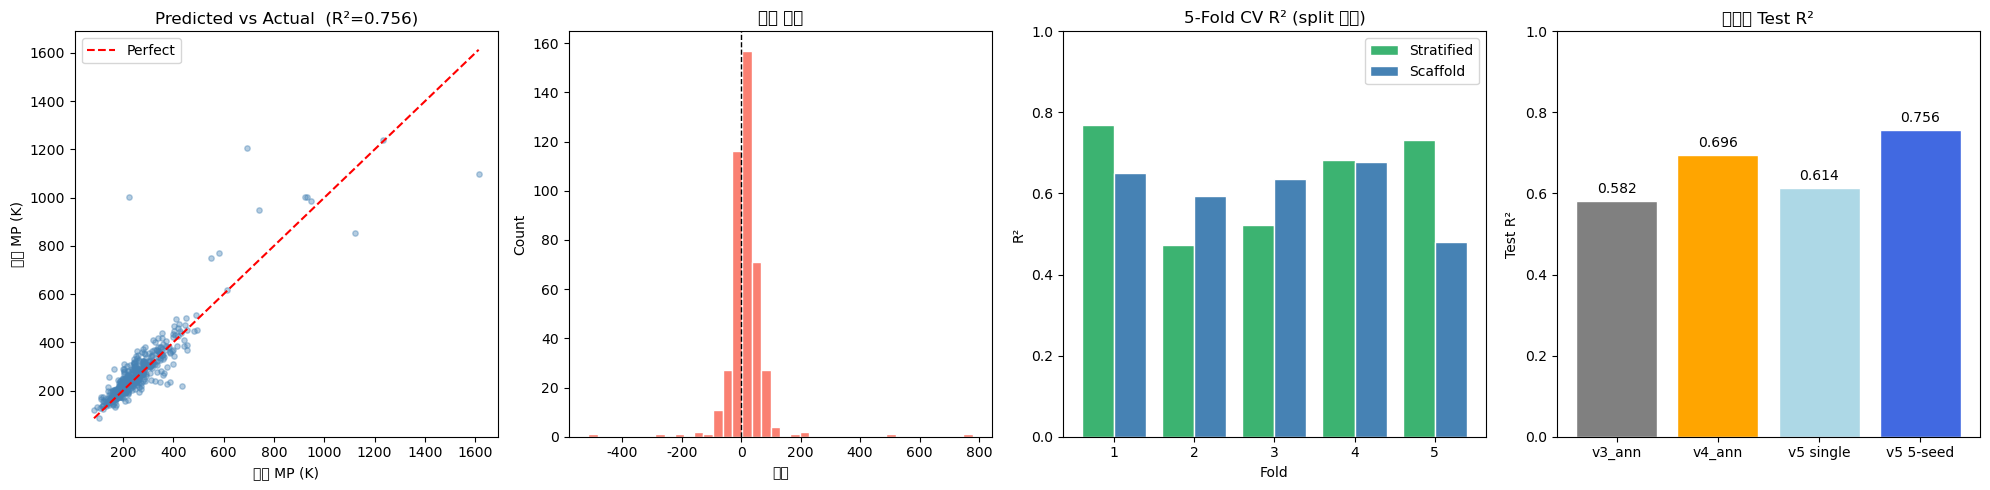

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

ax = axes[0]
ax.scatter(y_test, y_pred, alpha=0.4, s=15, color="steelblue")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect")
ax.set_xlabel("실제 MP (K)"); ax.set_ylabel("예측 MP (K)")
ax.set_title(f"Predicted vs Actual  (R²={test_r2:.3f})")
ax.legend()

ax = axes[1]
residuals = y_pred - y_test
ax.hist(residuals, bins=40, color="salmon", edgecolor="white")
ax.axvline(0, color="k", linestyle="--", linewidth=1)
ax.set_xlabel("잔차"); ax.set_ylabel("Count"); ax.set_title("잔차 분포")

ax = axes[2]
x_pos = np.arange(1, 6)
w = 0.4
ax.bar(x_pos - w/2, strat_r2, w, label="Stratified", color="mediumseagreen", edgecolor="white")
ax.bar(x_pos + w/2, scaf_r2,  w, label="Scaffold",   color="steelblue",   edgecolor="white")
ax.set_xlabel("Fold"); ax.set_ylabel("R²")
ax.set_title("5-Fold CV R² (split 비교)")
ax.set_ylim(0, 1); ax.legend()

ax = axes[3]
labels = ["v3_ann", "v4_ann", "v5 single", "v5 5-seed"]
vals   = [0.5821, 0.6958, single_r2, test_r2]
colors = ["gray", "orange", "lightblue", "royalblue"]
ax.bar(labels, vals, color=colors, edgecolor="white")
ax.set_ylabel("Test R²")
ax.set_title("버전별 Test R²")
ax.set_ylim(0, 1)
for i, v in enumerate(vals):
    ax.text(i, v + 0.02, f"{v:.3f}", ha="center")

plt.tight_layout()
plt.show()

## 13. 결과 요약 — v5 vs v6_chemberta

In [15]:
summary = pd.DataFrame({
    "버전": [
        "v5_ann Strat CV", "v5_ann Scaffold CV",
        "v5_ann single-seed Test", "v5_ann 5-seed Ensemble Test",
        "v6_cb Strat CV", "v6_cb Scaffold CV",
        "v6_cb single-seed Test", "v6_cb 5-seed Ensemble Test",
    ],
    "R²": [
        "0.6543", "0.6458", "0.7895", "0.7536",
        f"{np.mean(strat_r2):.4f}", f"{np.mean(scaf_r2):.4f}",
        f"{single_r2:.4f}", f"{test_r2:.4f}",
    ],
    "MAE / 편차": [
        "±0.140", "±0.065", "MAE 36.00", "MAE 32.00",
        f"±{np.std(strat_r2):.3f}", f"±{np.std(scaf_r2):.3f}",
        f"MAE {single_mae:.2f}", f"MAE {test_mae:.2f}",
    ],
})
print("=== v5 vs v6_chemberta 비교 ===")
print(f"노트북 전체 소요: {(time.time()-T0)/60:.1f}분")
print(f"MI top-300 중 ChemBERTa 비중: {bert_in_top_K}/{TOP_K} ({bert_in_top_K/TOP_K:.1%})")
summary

=== v5 vs v6_chemberta 비교 ===
노트북 전체 소요: 1.8분
MI top-300 중 ChemBERTa 비중: 7/300 (2.3%)


,버전,R²,MAE / 편차
0,v5_ann Strat CV,0.6543,±0.140
1,v5_ann Scaffold CV,0.6458,±0.065
2,v5_ann single-seed Test,0.7895,MAE 36.00
3,v5_ann 5-seed Ensemble Test,0.7536,MAE 32.00
4,v6_cb Strat CV,0.6362,±0.118
5,v6_cb Scaffold CV,0.6081,±0.069
6,v6_cb single-seed Test,0.6144,MAE 42.55
7,v6_cb 5-seed Ensemble Test,0.7558,MAE 35.71
